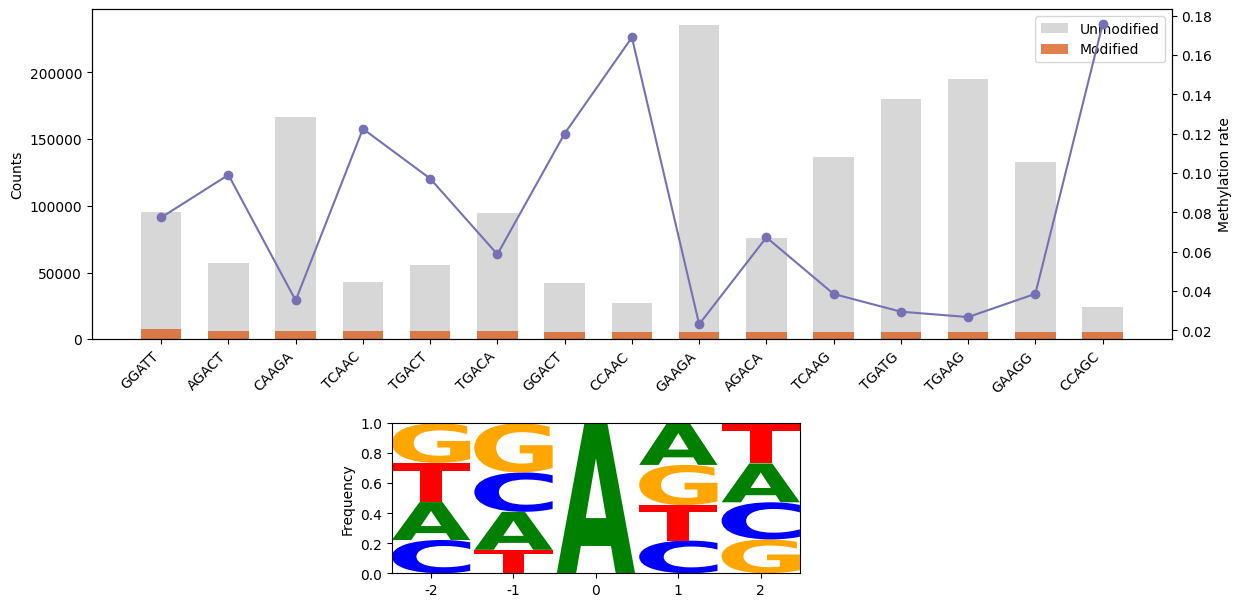

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import logomaker

# 1. 读入预测结果
# 格式：contig  position  motif  read_id  label  prob
df = pd.read_csv(
    "/mnt/sunxh/Datasets_RNA/P_trichocarpa/predict.p_trichocatpa.m6a.NNANN.tsv",     # 换成你的预测结果文件
    sep="\t",
    header=None,
    names=["contig", "pos", "motif", "read_id", "label", "prob"]
)

df["prob"] = df["prob"].astype(float)

# 2. 用概率阈值做二分类，只保留高置信度
probility = 0.89
df = df[(df["prob"] > probility) | (df["prob"] < 0.1)].copy()
df["status"] = np.where(df["prob"] > probility, "Modified", "Unmodified")

# 3. 按 5-mer motif 统计修饰 / 非修饰读段数
motif_stats = (
    df.groupby(["motif", "status"])
      .size()
      .unstack(fill_value=0)
)
for col in ["Modified", "Unmodified"]:
    if col not in motif_stats.columns:
        motif_stats[col] = 0

motif_stats["Total"]    = motif_stats["Modified"] + motif_stats["Unmodified"]
motif_stats["MethRate"] = motif_stats["Modified"] / motif_stats["Total"].replace(0, np.nan)


# 按“修饰数”从大到小
motif_stats = motif_stats.sort_values("Modified", ascending=False)
motif_stats.to_csv(
    "/mnt/sunxh/sunxh/wattmamba/new_result/supfig9_ptrichA.csv",
    sep="\t",
    index_label="motif"
)
motif_stats = motif_stats.head(15)

motifs = motif_stats.index.tolist()
x = np.arange(len(motifs))

# 颜色定义
import matplotlib.pyplot as plt
import logomaker
import pandas as pd
import numpy as np

# 颜色
color_unmod = "lightgray"
color_mod   = (218/255, 98/255, 33/255)
color_line  = (118/255, 113/255, 180/255)

x = np.arange(len(motif_stats))
motifs = motif_stats.index.tolist()

# ========= 创建一个 figure，上面柱状+折线，下面正方形 logo =========
fig = plt.figure(figsize=(12, 6))

# 上面大图：占据整宽度
ax_top = fig.add_axes([0.08, 0.40, 0.90, 0.55])   # [left, bottom, width, height]

bar_width = 0.6
ax_top.bar(
    x,
    motif_stats["Unmodified"],
    width=bar_width,
    label="Unmodified",
    color=color_unmod,
    alpha=0.9,
    zorder=1,
)
ax_top.bar(
    x,
    motif_stats["Modified"],
    width=bar_width,
    label="Modified",
    color=color_mod,
    alpha=0.8,
    zorder=2,
)

ax_top.set_ylabel("Counts")
ax_top.legend(loc="upper right")

ax_rate = ax_top.twinx()
ax_rate.plot(
    x,
    motif_stats["MethRate"],
    marker="o",
    linewidth=1.5,
    color=color_line,
    zorder=3,
)
ax_rate.set_ylabel("Methylation rate")

ax_top.set_xticks(x)
ax_top.set_xticklabels(motifs)
for label in ax_top.get_xticklabels():
    label.set_rotation(45)
    label.set_ha("right")

# ========= 下面小图（正方形 logo，居中） =========
# 这里 width == height，位置在底部居中
ax_logo = fig.add_axes([0.33, 0.01, 0.34, 0.25])

L = len(motifs[0])
bases = ["A", "C", "G", "T"]

mod_counts = df[df["status"] == "Modified"]["motif"].value_counts()

count_mat = pd.DataFrame(0, index=range(L), columns=bases)
for motif, w in mod_counts.items():
    if len(motif) != L:
        continue
    for i, b in enumerate(motif):
        if b in bases:
            count_mat.loc[i, b] += w

freq_mat = count_mat.div(count_mat.sum(axis=1), axis=0).fillna(0)
logomaker.Logo(freq_mat, ax=ax_logo)
ax_logo.set_ylabel("Frequency")
ax_logo.set_xticks(range(L))
ax_logo.set_xticklabels(range(-2, 3))
plt.savefig("/mnt/sunxh/sunxh/wattmamba/new_result/supfig9_ptrichA.pdf", dpi=1200, bbox_inches="tight")
plt.show()


In [10]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact

# 读取预测结果
m6 = pd.read_csv("/mnt/sunxh/Datasets_RNA/P_trichocarpa/predict.p_trichocatpa.m6a.NNANN.tsv", sep="\t",
                 header=None,
                 names=["contig", "pos", "motif", "read_id", "label", "prob"])
m1 = pd.read_csv("/mnt/sunxh/Datasets_RNA/P_trichocarpa/predict.p_trichocatpa.m1a.NNANN.tsv", sep="\t",
                 header=None,
                 names=["contig", "pos", "motif", "read_id", "label", "prob"])

# 统一类型
m6["prob"] = m6["prob"].astype(float)
m1["prob"] = m1["prob"].astype(float)

# 自己设定阈值：>0.9 认为该 read 在该位点是修饰
th_pos = 0.9
th_neg = 0.1    # 可用于背景分析，这里 2.4 不用

# ---------- 聚合到“位点级” ----------
def aggregate_site(df, prob_th):
    g = df.groupby(["contig", "pos"])
    out = g["prob"].agg(
        n_reads="size",
        n_mod=lambda x: (x > prob_th).sum(),
        mean_prob="mean"
    ).reset_index()
    out["frac_mod"] = out["n_mod"] / out["n_reads"]
    return out

m6_site = aggregate_site(m6, th_pos)
m1_site = aggregate_site(m1, th_pos)

cutoff_frac = 0.1

m6_site["is_m6A"] = (m6_site["frac_mod"] >= cutoff_frac).astype(int)
m1_site["is_m1A"] = (m1_site["frac_mod"] >= cutoff_frac).astype(int)

m6_site = m6_site[["contig", "pos", "is_m6A"]]
m1_site = m1_site[["contig", "pos", "is_m1A"]]

# ---------- 对齐 m6A / m1A 位点 ----------
sites = pd.merge(
    m6_site, m1_site,
    on=["contig", "pos"],
    how="outer"
).fillna(0)

sites["is_m6A"] = sites["is_m6A"].astype(int)
sites["is_m1A"] = sites["is_m1A"].astype(int)

# 2x2 统计
n11 = int(((sites["is_m6A"] == 1) & (sites["is_m1A"] == 1)).sum())
n10 = int(((sites["is_m6A"] == 1) & (sites["is_m1A"] == 0)).sum())
n01 = int(((sites["is_m6A"] == 0) & (sites["is_m1A"] == 1)).sum())
n00 = int(((sites["is_m6A"] == 0) & (sites["is_m1A"] == 0)).sum())

print("n11 (both m6A & m1A):", n11)
print("n10 (m6A only):", n10)
print("n01 (m1A only):", n01)
print("n00 (none):", n00)

jaccard = n11 / (n11 + n10 + n01 + 1e-9)
print("Jaccard index:", jaccard)

oddsratio, pvalue = fisher_exact([[n11, n10], [n01, n00]])
print("Fisher OR:", oddsratio)
print("Fisher p-value:", pvalue)


n11 (both m6A & m1A): 54937
n10 (m6A only): 48677
n01 (m1A only): 43063
n00 (none): 2634364
Jaccard index: 0.37454406621351427
Fisher OR: 69.0418844027643
Fisher p-value: 0.0


In [16]:
# 在这里保存
sites.to_csv(
    "/mnt/sunxh/sunxh/wattmamba/new_result/supfig9_ptrichB.csv",
    sep=",",
    index=False
)


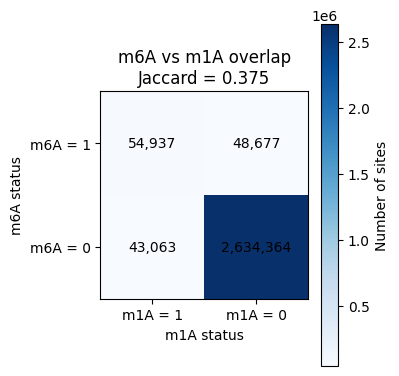

In [14]:
mat = np.array([[n11, n10],
                [n01, n00]], dtype=float)

fig, ax = plt.subplots(figsize=(4, 4))

im = ax.imshow(mat, cmap="Blues")

for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{int(mat[i, j]):,}",
                ha="center", va="center", color="black", fontsize=10)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["m1A = 1", "m1A = 0"])
ax.set_yticklabels(["m6A = 1", "m6A = 0"])

ax.set_xlabel("m1A status")
ax.set_ylabel("m6A status")
ax.set_title(
    f"m6A vs m1A overlap\n"
    f"Jaccard = {jaccard:.3f}"
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Number of sites")

plt.tight_layout()
plt.savefig("/mnt/sunxh/sunxh/wattmamba/new_result/supfig9_ptrichB.pdf", dpi=1200, bbox_inches="tight")
plt.show()


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 读入预测结果
m6 = pd.read_csv(
    "/mnt/sunxh/Datasets_RNA/P_trichocarpa/predict.p_trichocatpa.m6a.NNANN.tsv",
    sep="\t",
    header=None,
    names=["contig", "pos", "motif", "read_id", "label", "prob"],
)
m1 = pd.read_csv(
    "/mnt/sunxh/Datasets_RNA/P_trichocarpa/predict.p_trichocatpa.m1a.NNANN.tsv",
    sep="\t",
    header=None,
    names=["contig", "pos", "motif", "read_id", "label", "prob"],
)

m6["prob"] = m6["prob"].astype(float)
m1["prob"] = m1["prob"].astype(float)

# ---------- 按原版函数聚合到“位点级” ----------
def aggregate_site(df, prob_th):
    g = df.groupby(["contig", "pos"])
    out = g["prob"].agg(
        n_reads="size",
        n_mod=lambda x: (x > prob_th).sum(),
        mean_prob="mean",
    ).reset_index()
    out["frac_mod"] = out["n_mod"] / out["n_reads"]
    return out

th_pos = 0.9

m6_site = aggregate_site(m6, 0.9).rename(columns={"frac_mod": "frac_m6A"})
m1_site = aggregate_site(m1, 0.95).rename(columns={"frac_mod": "frac_m1A"})

# 只保留我们关心的列
m6_site = m6_site[["contig", "pos", "frac_m6A"]]
m1_site = m1_site[["contig", "pos", "frac_m1A"]]

sites = pd.merge(m6_site, m1_site, on=["contig", "pos"], how="outer").fillna(0.0)

mask = (sites["frac_m6A"] > 0) | (sites["frac_m1A"] > 0)
sub = sites[mask].copy()


In [36]:
sub.to_csv("/mnt/sunxh/sunxh/wattmamba/new_result/supfig9_ptrichC_site_fraction.csv", index=False)

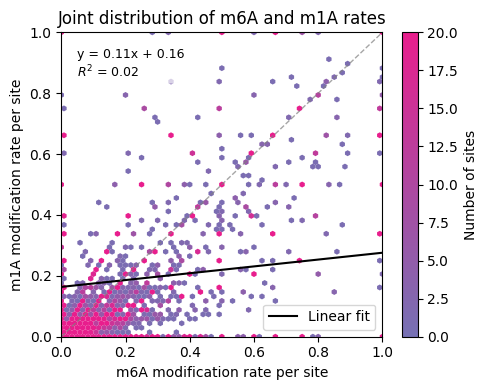

In [37]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# 两个端点颜色：RGB -> [0,1]
c1 = (118/255, 113/255, 180/255)   # 低密度
c2 = (232/255,  30/255, 141/255)   # 高密度

# 自定义线性渐变 colormap
custom_cmap = LinearSegmentedColormap.from_list(
    "m6a_m1a_cmap",
    [c1, c2]
)

fig, ax = plt.subplots(figsize=(5, 4))
# 拟合直线：m1A = a * m6A + b
x = sub["frac_m6A"].to_numpy()
y = sub["frac_m1A"].to_numpy()
mask_valid = np.isfinite(x) & np.isfinite(y)
a, b = np.polyfit(x[mask_valid], y[mask_valid], 1)

# 画拟合直线
x_line = np.linspace(0, 1, 100)
y_line = a * x_line + b
ax.plot(
    x_line,
    y_line,
    color="black",
    linestyle="-",
    linewidth=1.5,
    label="Linear fit"
)

# 可选：算一个 R^2 写在图上
y_pred = a * x[mask_valid] + b
ss_res = np.sum((y[mask_valid] - y_pred) ** 2)
ss_tot = np.sum((y[mask_valid] - y[mask_valid].mean()) ** 2)
r2 = 1 - ss_res / ss_tot

ax.text(
    0.05, 0.95,
    f"y = {a:.2f}x + {b:.2f}\n$R^2$ = {r2:.2f}",
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=9,
    bbox=dict(boxstyle="round", fc="white", ec="none", alpha=0.7),
)

ax.legend(loc="lower right")

hb = ax.hexbin(
    sub["frac_m6A"],
    sub["frac_m1A"],
    gridsize=60,
    cmap=custom_cmap,
    mincnt=1,
    linewidths=0,
    vmin=0,
    vmax=20      # 颜色和 colorbar 上限截到 4000
)
ax.set_xlabel("m6A modification rate per site")
ax.set_ylabel("m1A modification rate per site")
ax.set_title("Joint distribution of m6A and m1A rates")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.plot([0, 1], [0, 1], ls="--", lw=1, color="grey", alpha=0.7)

cb = fig.colorbar(hb, ax=ax)
cb.set_label("Number of sites")

plt.tight_layout()
plt.savefig("/mnt/sunxh/sunxh/wattmamba/new_result/supfig9_ptrichC_hexbin.pdf", dpi=1200, bbox_inches="tight")
plt.show()